## 1: Instalasi Library, Import Pustaka, dan Visualisasi Diagram Pipeline
Sel pertama ini menginstal pustaka `catboost` dan mengimpor seluruh pustaka pendukung untuk pengolahan data (`pandas`, `numpy`), algoritma *Machine Learning* (`xgboost`, `lightgbm`, `catboost`), penyeimbangan data distribusi (`SMOTE`), pembentukan kelompok data (`KMeans`), metrik evaluasi klasifikasi dari `sklearn`, serta pustaka pembuat grafik (`matplotlib`, `seaborn`, `graphviz`). Di bagian ini, sebuah diagram alur kerja (Pipeline Flowchart) dibangun dan diekspor sebagai gambar untuk memperlihatkan gambaran besar seluruh tahapan pemodelan.


In [9]:
!pip install pandas numpy scikit-learn imbalanced-learn xgboost lightgbm catboost matplotlib seaborn graphviz


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Visualisasi Pipeline berhasil dibuat: pipeline_flowchart.png


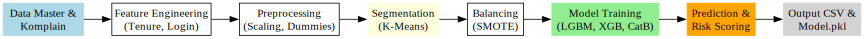

loading data master dan hasil komplain...

 TIPE PELANGGAN BERDASARKAN KEPARAHAN TIKET

distribusi 4 tipe pelanggan:
customer_type
satisfied      2525
at_risk         319
loyal_quiet     121
problematic      35
Name: count, dtype: int64

ringkasan:
- loyal_quiet   : tidak pernah komplain, anteng
- satisfied     : komplain ringan dan biasanya cepat diselesaikan
- at_risk       : lumayan sering komplain atau ada tiket yang nyangkut
- problematic   : komplainnya gawat (high/critical) dan banyak yang open
menghitung tenure_months dan days_since_login...


In [10]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn imbalanced-learn xgboost lightgbm catboost matplotlib seaborn graphviz
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

from graphviz import Digraph

# ==========================================
# 📊 VISUALISASI 0: Diagram Alur Pipeline
# ==========================================
dot = Digraph(comment='Churn Prediction Pipeline')
dot.attr(rankdir='LR', size='12,5')

# Define nodes with colors
dot.node('A', 'Data Master & \nKomplain', shape='box', style='filled', color='lightblue')
dot.node('B', 'Feature Engineering\n(Tenure, Login)', shape='box')
dot.node('C', 'Preprocessing\n(Scaling, Dummies)', shape='box')
dot.node('D', 'Segmentation\n(K-Means)', shape='box', style='filled', color='lightyellow')
dot.node('E', 'Balancing\n(SMOTE)', shape='box')
dot.node('F', 'Model Training\n(LGBM, XGB, CatB)', shape='box', style='filled', color='lightgreen')
dot.node('G', 'Prediction &\nRisk Scoring', shape='box', style='filled', color='orange')
dot.node('H', 'Output CSV &\nModel.pkl', shape='box', style='filled', color='lightgrey')

# Define edges
dot.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG', 'GH'])

# Simpan diagram
dot.render('pipeline_flowchart', format='png', cleanup=True)
print("✅ Visualisasi Pipeline berhasil dibuat: pipeline_flowchart.png")
display(dot)

# Setting style matplotlib
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'DejaVu Sans'

# ==========================================
# step 1: load data & integrasi data komplain
# ==========================================
print("loading data master dan hasil komplain...")
df = pd.read_csv('master_data_clean.csv')
df_komplain = pd.read_csv('hasil_komplain.csv')

# gabungin pakai atribut keparahan tiket (bukan sentimen lagi)
df = df.merge(df_komplain[['customer_id', 'avg_severity', 'severe_ticket_ratio', 'customer_type']], on='customer_id', how='left')

# isi data kosong (kalau ga pernah komplain, nilainya jadi 0)
df['avg_severity'] = df['avg_severity'].fillna(0)
df['severe_ticket_ratio'] = df['severe_ticket_ratio'].fillna(0)
df['customer_type'] = df['customer_type'].fillna('loyal_quiet')

print("\n" + "="*50)
print(" TIPE PELANGGAN BERDASARKAN KEPARAHAN TIKET")
print("="*50)
print("\ndistribusi 4 tipe pelanggan:")
print(df['customer_type'].value_counts())
print("\nringkasan:")
print("- loyal_quiet   : tidak pernah komplain, anteng")
print("- satisfied     : komplain ringan dan biasanya cepat diselesaikan")
print("- at_risk       : lumayan sering komplain atau ada tiket yang nyangkut")
print("- problematic   : komplainnya gawat (high/critical) dan banyak yang open")

# ==========================================
# step 2: feature engineering
# ==========================================
print("menghitung tenure_months dan days_since_login...")
df['subscription_date'] = pd.to_datetime(df['subscription_date'])
df['unsubscribed_date'] = pd.to_datetime(df['unsubscribed_date'])
df['last_login'] = pd.to_datetime(df['last_login'])

tanggal_acuan = pd.to_datetime('2024-12-31')
df['end_date'] = df['unsubscribed_date'].fillna(tanggal_acuan)
df['tenure_months'] = ((df['end_date'] - df['subscription_date']).dt.days / 30).round(1)

df['days_since_login'] = (df['end_date'] - df['last_login']).dt.days
df['days_since_login'] = df['days_since_login'].fillna(df['days_since_login'].median())

kolom_dibuang = ['customer_id', 'subscription_date', 'unsubscribed_date', 'last_login', 'end_date']
df_model = df.drop(columns=kolom_dibuang)

# ==========================================
# step 3: encoding pd.get_dummies & data splitting
# ==========================================
df_model = pd.get_dummies(df_model, columns=['plan_type', 'contract_type', 'customer_type'], drop_first=True)
for col in df_model.select_dtypes(include=['bool']).columns:
    df_model[col] = df_model[col].astype(int)

x = df_model.drop('is_churn', axis=1)
y = df_model['is_churn']

# WAJIB belah data DULU sebelum masuk tahap scaling dan k-means
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


## 2: Memuat Data, Integrasi Komplain, Rekayasa Fitur, dan Encoding
Memuat data pelanggan (`master_data_clean.csv`) dan data hasil komplain (`hasil_komplain.csv`). Kode menggabungkan kedua dataset tersebut untuk mendeteksi *Customer Type* berdasarkan tingkat keparahan tiket. Nilai kosong untuk pelanggan tanpa komplain otomatis diberi nilai 0 dan diberi label *Loyal Quiet*.
Sel ini kemudian melanjutkan ke tahap rekayasa fitur (*Feature Engineering*) dengan menghitung durasi berlangganan dalam bulan (`tenure_months`) serta jeda waktu sejak login terakhir pelanggan (`days_since_login`), lalu membuang fitur waktu yang tidak lagi digunakan. Proses ini diakhiri dengan *One-Hot Encoding* untuk variabel kategori dan memisahkannya menjadi data latih dan uji menggunakan fungsi `train_test_split`.


In [11]:
# ==========================================
# step 1: load data & integrasi data komplain
# ==========================================
print("loading data master dan hasil komplain...")
df = pd.read_csv('master_data_clean.csv')
df_komplain = pd.read_csv('hasil_komplain.csv')

# gabungin pakai atribut keparahan tiket (bukan sentimen lagi)
df = df.merge(df_komplain[['customer_id', 'avg_severity', 'severe_ticket_ratio', 'customer_type']], on='customer_id', how='left')

# isi data kosong (kalau ga pernah komplain, nilainya jadi 0)
df['avg_severity'] = df['avg_severity'].fillna(0)
df['severe_ticket_ratio'] = df['severe_ticket_ratio'].fillna(0)
df['customer_type'] = df['customer_type'].fillna('loyal_quiet')

print("\n" + "="*50)
print(" TIPE PELANGGAN BERDASARKAN KEPARAHAN TIKET")
print("="*50)
print("\ndistribusi 4 tipe pelanggan:")
print(df['customer_type'].value_counts())
print("\nringkasan:")
print("- loyal_quiet   : tidak pernah komplain, anteng")
print("- satisfied     : komplain ringan dan biasanya cepat diselesaikan")
print("- at_risk       : lumayan sering komplain atau ada tiket yang nyangkut")
print("- problematic   : komplainnya gawat (high/critical) dan banyak yang open")

# ==========================================
# step 2: feature engineering
# ==========================================
print("menghitung tenure_months dan days_since_login...")
df['subscription_date'] = pd.to_datetime(df['subscription_date'])
df['unsubscribed_date'] = pd.to_datetime(df['unsubscribed_date'])
df['last_login'] = pd.to_datetime(df['last_login'])

tanggal_acuan = pd.to_datetime('2024-12-31')
df['end_date'] = df['unsubscribed_date'].fillna(tanggal_acuan)
df['tenure_months'] = ((df['end_date'] - df['subscription_date']).dt.days / 30).round(1)

df['days_since_login'] = (df['end_date'] - df['last_login']).dt.days
df['days_since_login'] = df['days_since_login'].fillna(df['days_since_login'].median())

kolom_dibuang = ['customer_id', 'subscription_date', 'unsubscribed_date', 'last_login', 'end_date']
df_model = df.drop(columns=kolom_dibuang)

# ==========================================
# step 3: encoding pd.get_dummies & data splitting
# ==========================================
df_model = pd.get_dummies(df_model, columns=['plan_type', 'contract_type', 'customer_type'], drop_first=True)
for col in df_model.select_dtypes(include=['bool']).columns:
    df_model[col] = df_model[col].astype(int)

x = df_model.drop('is_churn', axis=1)
y = df_model['is_churn']

# WAJIB belah data DULU sebelum masuk tahap scaling dan k-means
# ⚠️ Pemisahan data ini sengaja dilakukan sebelum scaling dan K-Means. Ini penting untuk mencegah data leakage (bocornya informasi test set ke proses training).
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

loading data master dan hasil komplain...

 TIPE PELANGGAN BERDASARKAN KEPARAHAN TIKET

distribusi 4 tipe pelanggan:
customer_type
satisfied      2525
at_risk         319
loyal_quiet     121
problematic      35
Name: count, dtype: int64

ringkasan:
- loyal_quiet   : tidak pernah komplain, anteng
- satisfied     : komplain ringan dan biasanya cepat diselesaikan
- at_risk       : lumayan sering komplain atau ada tiket yang nyangkut
- problematic   : komplainnya gawat (high/critical) dan banyak yang open
menghitung tenure_months dan days_since_login...


## Visualisasi Distribusi Tipe Pelanggan
Membuat visualisasi berupa persentase diagram untuk menunjukkan proporsi dari pelanggan berdasarkan tingkat keparahan tiket komplain mereka. Empat label yang divisualisasikan adalah *Loyal Quiet*, *Satisfied*, *At Risk*, dan *Problematic*, sehingga persentase dominasi perilaku komplain dapat terekam secara jelas.


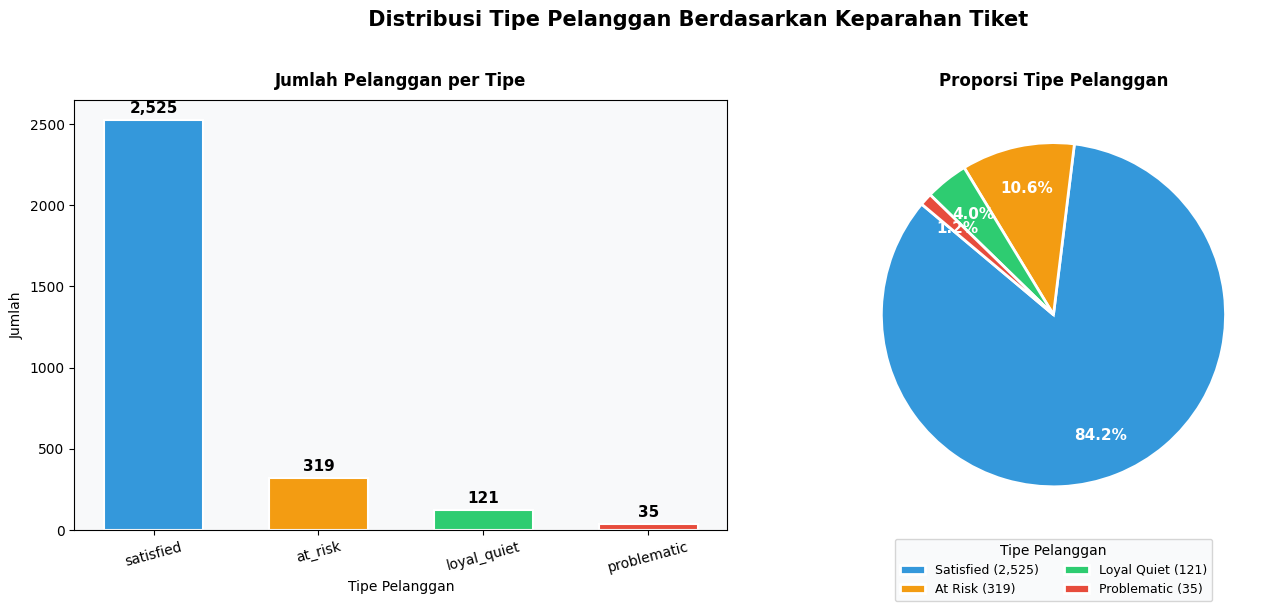

 Visualisasi 1 tersimpan: viz1_customer_type_distribution.png


In [12]:
# ==========================================
# VISUALISASI 1: Distribusi Tipe Pelanggan
# ==========================================
customer_type_counts = df['customer_type'].value_counts()

colors = {
    'loyal_quiet':  '#2ecc71',
    'satisfied':    '#3498db',
    'at_risk':      '#f39c12',
    'problematic':  '#e74c3c'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(' Distribusi Tipe Pelanggan Berdasarkan Keparahan Tiket',
             fontsize=15, fontweight='bold', y=1.02)

# Bar chart
bar_colors = [colors.get(ct, '#95a5a6') for ct in customer_type_counts.index]
bars = axes[0].bar(customer_type_counts.index, customer_type_counts.values,
                    color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)
axes[0].set_title('Jumlah Pelanggan per Tipe', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Tipe Pelanggan', fontsize=10)
axes[0].set_ylabel('Jumlah', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, customer_type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(customer_type_counts)*0.01,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart
pie_colors = [colors.get(ct, '#95a5a6') for ct in customer_type_counts.index]
wedges, texts, autotexts = axes[1].pie(
    customer_type_counts.values,
    labels=None,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

legend_labels = [f'{ct.replace("_", " ").title()} ({v:,})'
                 for ct, v in zip(customer_type_counts.index, customer_type_counts.values)]
axes[1].legend(wedges, legend_labels, title="Tipe Pelanggan", loc="lower center",
               bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9, title_fontsize=10)
axes[1].set_title('Proporsi Tipe Pelanggan', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('viz1_customer_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisasi 1 tersimpan: viz1_customer_type_distribution.png")


## 4: Normalisasi Skala Data (Scaling)
Membangun pemroses normalisasi variabel dengan fungsi `StandardScaler` dari data latih (*training data*). Parameter normalisasi tersebut lalu diterapkan merata terhadap data latih, data uji, serta seluruh sisa data sebelum dikonversi kembali menjadi format *DataFrame*. Hal ini diwajibkan untuk menjamin nilai algoritma prediksi tidak melenceng.

-StandardScaler di-fit hanya dari data training, lalu hasilnya di-transform ke tiga versi:

x_train_scaled — data latih yang sudah dinormalisasi
x_test_scaled — data uji (pakai parameter dari training, bukan di-fit ulang)
x_all_scaled — semua data (untuk prediksi akhir)

-Model K-Means dengan 4 cluster di-fit dari data training yang sudah di-scale. Cluster ini merepresentasikan segmen perilaku pelanggan secara otomatis. 
Hasilnya ditambahkan sebagai fitur baru customer_segment ke masing-masing split data. 
Model K-Means hanya di-fit di training, sedangkan test dan all-data cukup di-predict.


In [13]:
# ==========================================
# step 4: scaling murni anti bocor
# ==========================================
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_all_scaled = scaler.transform(x)

x_train_df = pd.DataFrame(x_train_scaled, columns=x.columns)
x_test_df = pd.DataFrame(x_test_scaled, columns=x.columns)
x_all_df = pd.DataFrame(x_all_scaled, columns=x.columns)

# ==========================================
# step 5: data mining (k-means) anti bocor
# ==========================================
print("membuat segmentasi k-means...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
x_train_df['customer_segment'] = kmeans.fit_predict(x_train_df)
x_test_df['customer_segment'] = kmeans.predict(x_test_df)
x_all_df['customer_segment'] = kmeans.predict(x_all_df)

# ==========================================
# step 6: smote
# ==========================================
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_df, y_train)
print(f"Data setelah SMOTE - Churn: {sum(y_train_smote==1):,}, Non-Churn: {sum(y_train_smote==0):,}")


membuat segmentasi k-means...
Data setelah SMOTE - Churn: 1,230, Non-Churn: 1,230


## 5: K-Means Clustering (Visualisasi Segmentasi Pelanggan)
Menggunakan algoritma *K-Means* untuk membentuk 4 segmen karakter pelanggan baru. Selain melatih model segmentasi otomatis tersebut, komponen pereduksi dimensi *Principal Component Analysis* (PCA) digunakan untuk meringkas matriks multidimensi dan menampilkan grafik visual dua dimensi yang membentangkan persebaran *cluster* tersebut dengan rapi.

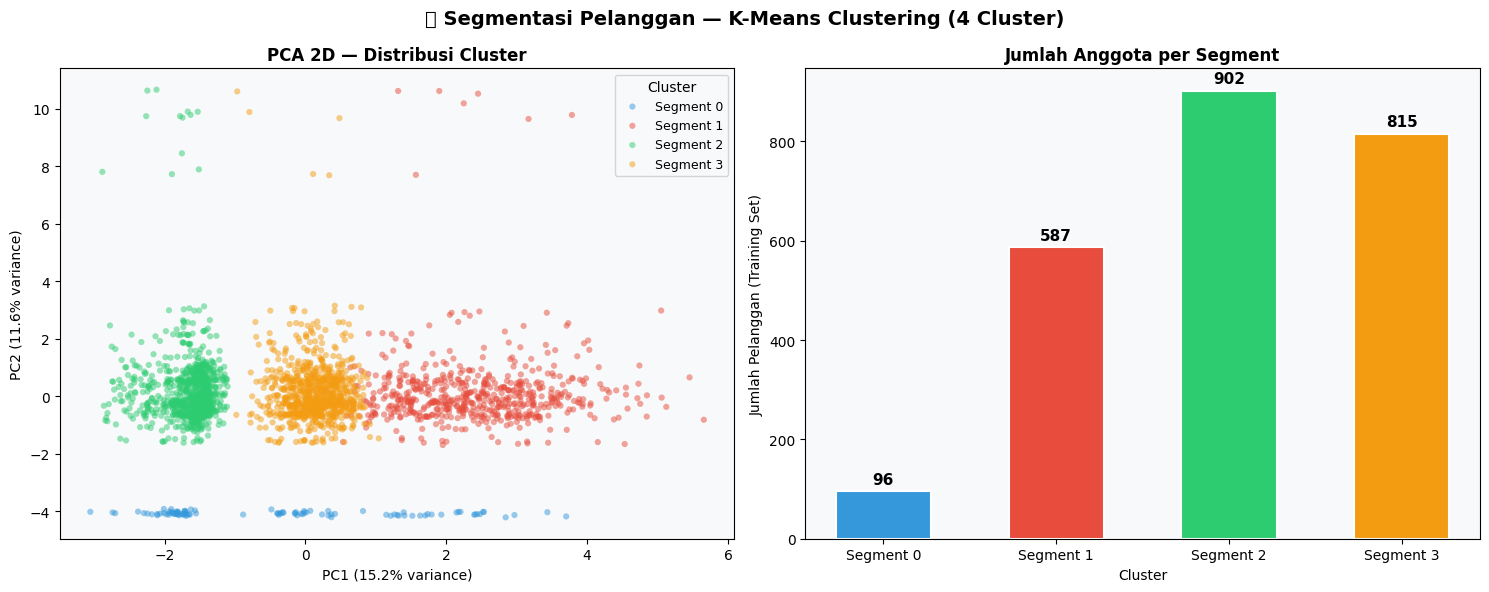

✅ Visualisasi 2 tersimpan: viz2_kmeans_segmentation.png


In [14]:
# ==========================================
#  VISUALISASI 2: K-Means Cluster Segmentasi Pelanggan
# ==========================================
# Reduksi dimensi pake PCA buat visualisasi 2D
pca = PCA(n_components=2, random_state=42)
x_train_pca = pca.fit_transform(x_train_df.drop(columns=['customer_segment']))

cluster_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
cluster_labels = [f'Segment {i}' for i in range(4)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('🔵 Segmentasi Pelanggan — K-Means Clustering (4 Cluster)',
             fontsize=14, fontweight='bold')

# Scatter PCA
for seg in range(4):
    mask = x_train_df['customer_segment'] == seg
    axes[0].scatter(x_train_pca[mask, 0], x_train_pca[mask, 1],
                    c=cluster_colors[seg], label=cluster_labels[seg],
                    alpha=0.5, s=20, edgecolors='none')
axes[0].set_title('PCA 2D — Distribusi Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
axes[0].legend(title='Cluster', fontsize=9)

# Bar chart jumlah per segment
seg_counts = x_train_df['customer_segment'].value_counts().sort_index()
bars = axes[1].bar(cluster_labels, seg_counts.values, color=cluster_colors,
                    edgecolor='white', linewidth=1.5, width=0.55)
axes[1].set_title('Jumlah Anggota per Segment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=10)
axes[1].set_ylabel('Jumlah Pelanggan (Training Set)', fontsize=10)
for bar, val in zip(bars, seg_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(seg_counts)*0.01,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('viz2_kmeans_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi 2 tersimpan: viz2_kmeans_segmentation.png")

# #Interpretasi 4 Segmen K-Means
# 🔵 Segment 0 — "Outlier / Edge Case"
# Jumlah: 96 pelanggan (paling sedikit) Di PCA scatter, posisinya terpisah jauh di bawah (PC2 sekitar -4), jauh dari cluster lain
# Ini menandakan pelanggan dengan profil sangat berbeda dari mayoritas — kemungkinan besar ini pelanggan dengan nilai ekstrem, misalnya tenure sangat panjang tapi tiba-tiba hilang, atau churn score sangat tinggi
# Kandidat kuat: pelanggan problematic / sudah churn confirmed
# 🔴 Segment 1 — "Pelanggan Biasa Aktif"
# Jumlah: 587 pelanggan
# Di PCA tersebar di tengah-kanan (PC1 positif), cukup menyebar luas
# Profil tengah-tengah, tidak terlalu loyal tapi tidak terlalu berisiko
# Kandidat: pelanggan aktif dengan risiko churn sedang
# 🟢 Segment 2 — "Pelanggan Mayoritas / Loyal"
# Jumlah: 902 pelanggan (terbanyak)
# Di PCA menumpuk padat di kiri (PC1 negatif, sekitar -2), cluster yang paling rapat
# Cluster yang paling homogen — artinya profil pelanggannya mirip-mirip satu sama lain
# Kandidat: pelanggan loyal, tenure panjang, jarang komplain
# #🟡 Segment 3 — "Pelanggan Transisi / At Risk"
# Jumlah: 815 pelanggan
# Di PCA posisinya overlap dengan Segment 1 dan 2, berada di tengah
# Profil peralihan — belum separah Segment 0 tapi sudah mulai menunjukkan tanda-tanda
# Kandidat: pelanggan yang mulai jarang login atau mulai komplain


## 6: Pelatihan 3 Model Machine Learning Utama
Pada tahapan krusial ini, tiga algoritma berkinerja tinggi dijalankan sekaligus untuk menganalisis dan mendeteksi kondisi churn: *LightGBM*, *XGBoost*, dan *CatBoost*. Setiap model dipacu secara individual menggunakan data set latih yang terimputasi seimbang. Kode kemudian menghitung dan mencetak rangkuman evaluasi metrik seperti parameter Akurasi, *AUC-ROC*, Presisi, *Recall*, dan metrik F1-Score dari setiap prediksinya.

Step 7 — Training 3 Model
Tiga model dilatih menggunakan data training hasil SMOTE:

LightGBM — dikonfigurasi dengan hyperparameter cukup detail (1000 estimator, learning rate 0.01, num_leaves 127, dll.)
XGBoost — dengan konfigurasi default
CatBoost — dengan verbose=0

Masing-masing dievaluasi di test set, dan model terbaik dipilih berdasarkan akurasi tertinggi. Setelah itu, model terpilih dikalibrasi menggunakan CalibratedClassifierCV dengan metode sigmoid agar probabilitas outputnya lebih terpercaya dan terdistribusi natural (tidak menumpuk di ujung 0 atau 1).

In [15]:
# ==========================================
# step 7: training 3 model andalan
# ==========================================
print("\n" + "="*50)
print("🚀 training lightgbm, xgboost, dan catboost")
print("="*50)

lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1,
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=127,
    max_depth=9,
    min_child_samples=10,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.9,
    reg_alpha=0.01,
    reg_lambda=0.01,
    min_split_gain=0.001,
    scale_pos_weight=1.2,
    boosting_type='gbdt'
)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
cat = CatBoostClassifier(random_state=42, verbose=0)

models = [lgbm, xgb, cat]
model_names = ['LightGBM', 'XGBoost', 'CatBoost']

results = {}

for i, model in enumerate(models):
    model.fit(x_train_smote, y_train_smote)
    y_pred = model.predict(x_test_df)
    y_proba = model.predict_proba(x_test_df)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[model_names[i]] = {
        'auc_roc': auc,
        'accuracy': acc,
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1_1': report['1']['f1-score'],
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"\n hasil evaluasi model: {model_names[i]}")
    print("-" * 50)
    print(f"auc-roc score : {auc:.4f}")
    print(f"accuracy      : {acc:.4f}")
    print(classification_report(y_test, y_pred))

# ✅ PILIH MODEL TERBAIK BERDASARKAN AKURASI TERTINGGI
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_model_idx = model_names.index(best_model_name)
best_model = models[best_model_idx]

print("\n" + "="*50)
print(f"🏆 MODEL TERPILIH: {best_model_name}")
print(f"   Accuracy : {results[best_model_name]['accuracy']:.4f}")
print(f"   AUC-ROC  : {results[best_model_name]['auc_roc']:.4f}")
print("="*50)

# ==========================================
# step 7b: kalibrasi probabilitas model
# ==========================================
from sklearn.calibration import CalibratedClassifierCV

print("\n" + "="*50)
print("🔧 kalibrasi probabilitas model terpilih")
print("="*50)

# sigmoid lebih smooth dari isotonic untuk distribusi bimodal
calibrated_model = CalibratedClassifierCV(best_model, cv='prefit', method='sigmoid')
calibrated_model.fit(x_train_smote, y_train_smote)  # fit di training, bukan test

# perbandingan sebelum vs sesudah kalibrasi
y_proba_raw = best_model.predict_proba(x_all_df)[:, 1]
y_proba_cal = calibrated_model.predict_proba(x_all_df)[:, 1]

print(f"\nSebelum kalibrasi (semua data):")
print(f"  25% : {np.percentile(y_proba_raw*100, 25):.2f}")
print(f"  50% : {np.percentile(y_proba_raw*100, 50):.2f}")
print(f"  75% : {np.percentile(y_proba_raw*100, 75):.2f}")

print(f"\nSesudah kalibrasi (semua data):")
print(f"  25% : {np.percentile(y_proba_cal*100, 25):.2f}")
print(f"  50% : {np.percentile(y_proba_cal*100, 50):.2f}")
print(f"  75% : {np.percentile(y_proba_cal*100, 75):.2f}")

print("\n✅ kalibrasi selesai")


🚀 training lightgbm, xgboost, dan catboost

 hasil evaluasi model: LightGBM
--------------------------------------------------
auc-roc score : 0.9695
accuracy      : 0.9383
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       293
           1       0.96      0.92      0.94       307

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600


 hasil evaluasi model: XGBoost
--------------------------------------------------
auc-roc score : 0.9647
accuracy      : 0.9267
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       293
           1       0.94      0.91      0.93       307

    accuracy                           0.93       600
   macro avg       0.93      0.93      0.93       600
weighted avg       0.93      0.93      0.93       600


 hasil evaluasi model: CatBoost
----------

In [20]:
from xgboost import XGBClassifier

for name, obj in list(globals().items()):
    if isinstance(obj, XGBClassifier):
        print(f"{name} → XGBClassifier")

Menjalankan 10-Fold Cross Validation...
LightGBM : 0.9283 ± 0.0089
XGBoost  : 0.9221  ± 0.0129
CatBoost : 0.9300  ± 0.0100

── Hasil Paired T-test ────────────────────────────────
LightGBM vs XGBoost  → t=1.6948, p=0.1244 ❌ Tidak Signifikan
LightGBM vs CatBoost → t=-0.8847, p=0.3994 ❌ Tidak Signifikan
XGBoost  vs CatBoost → t=-1.9562, p=0.0821 ❌ Tidak Signifikan


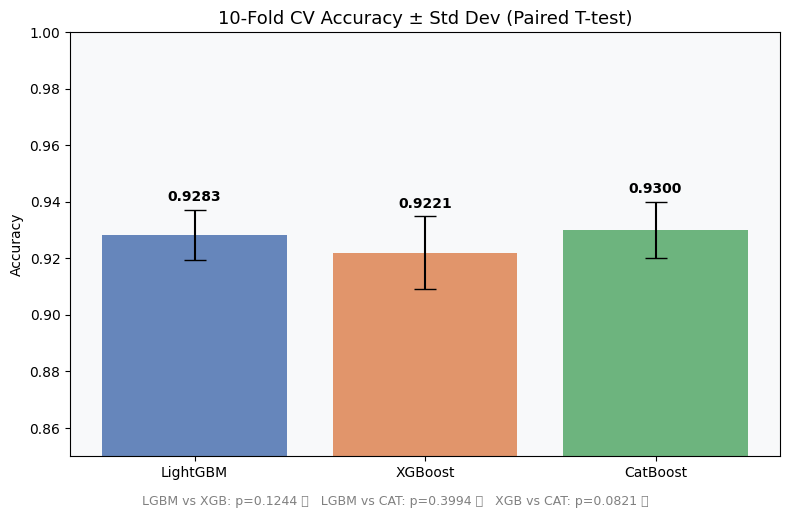

In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy import stats
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt

# ── Fit XGBoost ─────────────────────────────────────────────────────
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(x_train_scaled, y_train)

# ── Cross Validation ────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=10, shuffle=False)
X_cv = x_train_scaled
y_cv = y_train

print("Menjalankan 10-Fold Cross Validation...")
scores_lgbm = cross_val_score(lgbm, X_cv, y_cv, cv=cv, scoring='accuracy')
scores_xgb  = cross_val_score(xgb,  X_cv, y_cv, cv=cv, scoring='accuracy')
scores_cat  = cross_val_score(cat,  X_cv, y_cv, cv=cv, scoring='accuracy')

print(f"LightGBM : {scores_lgbm.mean():.4f} ± {scores_lgbm.std():.4f}")
print(f"XGBoost  : {scores_xgb.mean():.4f}  ± {scores_xgb.std():.4f}")
print(f"CatBoost : {scores_cat.mean():.4f}  ± {scores_cat.std():.4f}")

# ── Paired T-test ───────────────────────────────────────────────────
print("\n── Hasil Paired T-test ────────────────────────────────")

result1 = stats.ttest_rel(scores_lgbm, scores_xgb)
result2 = stats.ttest_rel(scores_lgbm, scores_cat)
result3 = stats.ttest_rel(scores_xgb,  scores_cat)

print(f"LightGBM vs XGBoost  → t={result1.statistic:.4f}, p={result1.pvalue:.4f}",
      "✅ Signifikan" if result1.pvalue < 0.05 else "❌ Tidak Signifikan")
print(f"LightGBM vs CatBoost → t={result2.statistic:.4f}, p={result2.pvalue:.4f}",
      "✅ Signifikan" if result2.pvalue < 0.05 else "❌ Tidak Signifikan")
print(f"XGBoost  vs CatBoost → t={result3.statistic:.4f}, p={result3.pvalue:.4f}",
      "✅ Signifikan" if result3.pvalue < 0.05 else "❌ Tidak Signifikan")

# ── Visualisasi ─────────────────────────────────────────────────────
model_names = ['LightGBM', 'XGBoost', 'CatBoost']
all_scores  = [scores_lgbm, scores_xgb, scores_cat]
means = [s.mean() for s in all_scores]
stds  = [s.std()  for s in all_scores]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(model_names, means, yerr=stds, capsize=8,
       color=['#4C72B0', '#DD8452', '#55A868'], alpha=0.85)
ax.set_title('10-Fold CV Accuracy ± Std Dev (Paired T-test)', fontsize=13)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.85, 1.0)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.003, f"{m:.4f}", ha='center', fontsize=10, fontweight='bold')

pval_text = (f"LGBM vs XGB: p={result1.pvalue:.4f} {'✅' if result1.pvalue < 0.05 else '❌'}   "
             f"LGBM vs CAT: p={result2.pvalue:.4f} {'✅' if result2.pvalue < 0.05 else '❌'}   "
             f"XGB vs CAT: p={result3.pvalue:.4f} {'✅' if result3.pvalue < 0.05 else '❌'}")
fig.text(0.5, -0.02, pval_text, ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

## 7: Visualisasi Pentingnya Fitur (Feature Importance)
Bertugas mengekstrak besaran kontribusi fitur utama yang memicu indikasi churn menggunakan kemampuan identifikasi dari model yang paling dominan (*LightGBM*). Plot diagram batang horizontal bergaya modern digambar menggunakan modul *Seaborn* untuk menyoroti peringkat 10 nilai kolom apa saja yang paling memberikan pengaruh penentuan bagi keputusan *machine learning* tersebut.


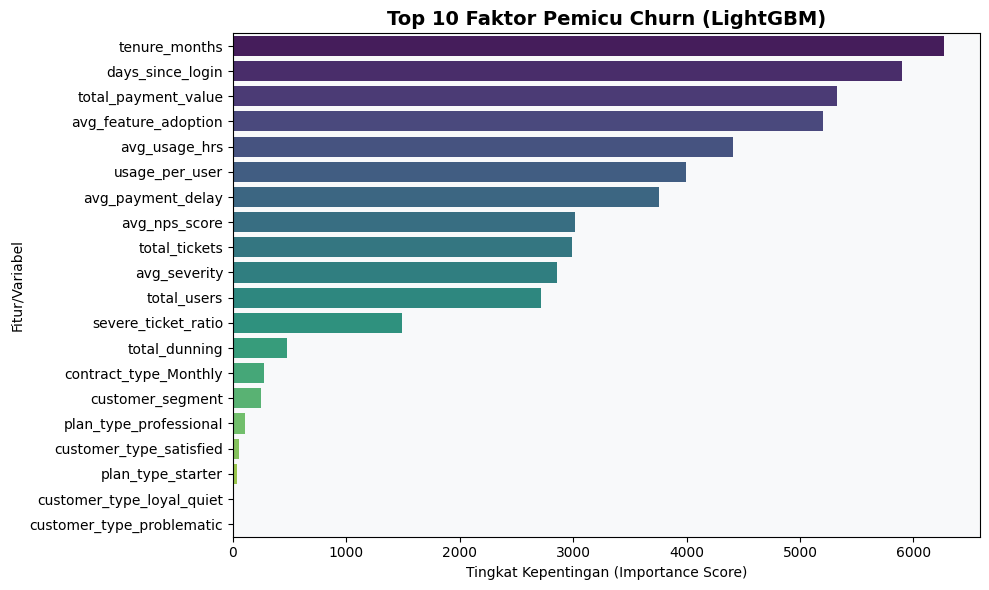

✅ Visualisasi 6 tersimpan: viz6_feature_importance.png


In [ ]:
# ==========================================
# 📊 VISUALISASI 6: Feature Importance (Pemicu Churn)
# ==========================================
# Mengambil importance dari model terpilih (LightGBM)
importances = best_model.feature_importances_
feature_names = x_train_smote.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 10 Faktor Pemicu Churn (LightGBM)', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Fitur/Variabel')
plt.tight_layout()
plt.savefig('viz6_feature_importance.png', dpi=150)
plt.show()
print("✅ Visualisasi 6 tersimpan: viz6_feature_importance.png")



## 8: Visualisasi Perbandingan Kinerja Metrik Klasifikasi
Ini merangkum dan membandingkan secara komparatif catatan skor *AUC-ROC*, persentase Akurasi, serta performa F1-Score dan klasifikasi spesifik dari seluruh iterasi eksperimen 3 model: *LightGBM*, *XGBoost*, serta *CatBoost*. Tabel dan grafik tersebut diproduksi agar analis teknis dapat menyimpulkan model tunggal mana yang terbaik.

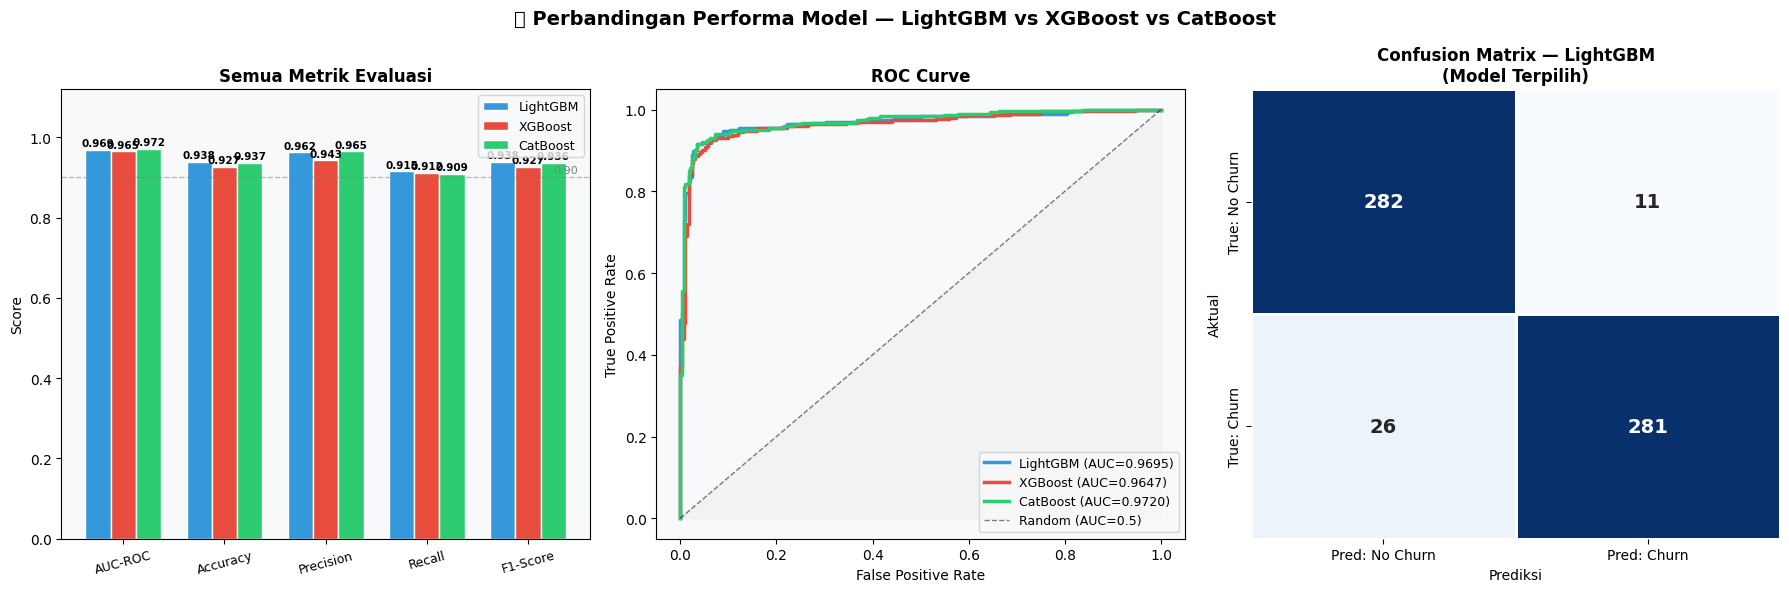

✅ Visualisasi 3 tersimpan: viz3_model_performance.png


In [ ]:
# ==========================================
#  VISUALISASI 3: Perbandingan Performa 3 Model
# ==========================================
from sklearn.metrics import roc_curve

metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC-ROC': [results[m]['auc_roc'] for m in results],
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision (Churn)': [results[m]['precision_1'] for m in results],
    'Recall (Churn)': [results[m]['recall_1'] for m in results],
    'F1-Score (Churn)': [results[m]['f1_1'] for m in results],
})

model_colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🚀 Perbandingan Performa Model — LightGBM vs XGBoost vs CatBoost',
             fontsize=14, fontweight='bold')

# --- Panel 1: grouped bar chart semua metrik ---
metric_cols = ['AUC-ROC', 'Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1-Score (Churn)']
x_pos = np.arange(len(metric_cols))
width = 0.25

for idx, (model_name, color) in enumerate(zip(results.keys(), model_colors)):
    vals = [results[model_name]['auc_roc'], results[model_name]['accuracy'],
            results[model_name]['precision_1'], results[model_name]['recall_1'], results[model_name]['f1_1']]
    bars = axes[0].bar(x_pos + idx*width, vals, width, label=model_name, color=color,
                        edgecolor='white', linewidth=1)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

axes[0].set_title('Semua Metrik Evaluasi', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos + width)
axes[0].set_xticklabels(['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
                          fontsize=9, rotation=15)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('Score', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)
axes[0].text(4.5, 0.91, '0.90', color='gray', fontsize=8)

# --- Panel 2: ROC Curve ---
for model_name, color in zip(results.keys(), model_colors):
    fpr, tpr, _ = roc_curve(y_test, results[model_name]['y_proba'])
    axes[1].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f"{model_name} (AUC={results[model_name]['auc_roc']:.4f})")
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
axes[1].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].legend(fontsize=9, loc='lower right')

# --- Panel 3: Confusion Matrix LightGBM (model terpilih) ---
cm = confusion_matrix(y_test, results['LightGBM']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Pred: No Churn', 'Pred: Churn'],
            yticklabels=['True: No Churn', 'True: Churn'],
            linewidths=1, linecolor='white', cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
axes[2].set_title('Confusion Matrix — LightGBM\n(Model Terpilih)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Prediksi', fontsize=10)
axes[2].set_ylabel('Aktual', fontsize=10)

plt.tight_layout()
plt.savefig('viz3_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi 3 tersimpan: viz3_model_performance.png")


## 9: Prediksi Akhir dan Pembuatan Laporan Risiko (Export CSV)
Sel ini mengutus model terbaik (yaitu *LightGBM*) untuk mengeksekusi probabilitas keputusan aktual atas keseluruhan *database* klien. Skor nilai persentase kemungkinan dipetakan ke sistem persentase skala 0 hingga 100 (*Churn Score*). Sistem lantas membaginya berdasarkan parameter kelompok risiko (Risiko Tinggi, Sedang, atau Rendah). Rekap parameter final ini digabungkan secara utuh lalu diunduh menjadi berkas ekspor tabel `.csv` siap pakai (`churn_prediction_results.csv`).

In [ ]:
# ==========================================
# step 8: prediksi final & export csv
# ==========================================
print("\n" + "="*50)
print(" hasil prediksi final")
print("="*50)

# pakai calibrated_model, bukan models[0]
final_predictions = calibrated_model.predict(x_test_df)
akurasi_akhir = accuracy_score(y_test, final_predictions)

print(f"model terpilih      : {best_model_name} (terkalibrasi)")
print(f"akurasi keputusan   : {akurasi_akhir:.4f}")

# pakai calibrated_model untuk semua data
probabilitas_semua = calibrated_model.predict_proba(x_all_df)[:, 1]
df['churn_score'] = (probabilitas_semua * 100).round(1)

def tentukan_risiko(skor):
    if skor >= 70:
        return 'High'
    elif skor >= 30:
        return 'Medium'
    else:
        return 'Low'

df['risk_level'] = df['churn_score'].apply(tentukan_risiko)
df = df.rename(columns={'is_churn': 'churn'})

# cek distribusi risk level hasil kalibrasi
print("\nDistribusi Risk Level setelah kalibrasi:")
print(df['risk_level'].value_counts())
print(f"\nDistribusi churn_score:")
print(f"  25% : {df['churn_score'].quantile(0.25):.1f}")
print(f"  50% : {df['churn_score'].quantile(0.50):.1f}")
print(f"  75% : {df['churn_score'].quantile(0.75):.1f}")


 hasil prediksi final
model terpilih      : LightGBM (terkalibrasi)
akurasi keputusan   : 0.9383

Distribusi Risk Level setelah kalibrasi:
risk_level
High      1519
Low       1475
Medium       6
Name: count, dtype: int64

Distribusi churn_score:
  25% : 0.1
  50% : 99.5
  75% : 99.9


## 10: Visualisasi Distribusi Skor Churn dan Tingkat Risiko Pelanggan
Sel ini bertugas menelan *file* CSV data laporan final hasil prediksi probabilitas pada fase terdahulu. Skrip ini melukiskan komposisi secara tiga sisi bersebelahan yang merangkum kurva intensitas sebaran dari nilai numerik *Churn Score* sekaligus grafik komposisi komparasi untuk melihat proporsi tingkat level bahaya pelanggan dalam bentuk ringkasan diagram *dashboard*.


In [ ]:
# ==========================================
# step 8: prediksi final & export csv
# ==========================================
from scipy.stats import rankdata

print("\n" + "="*50)
print(" hasil prediksi final")
print("="*50)

final_predictions = best_model.predict(x_test_df)
akurasi_akhir = accuracy_score(y_test, final_predictions)
print(f"model terpilih      : {best_model_name}")
print(f"akurasi keputusan   : {akurasi_akhir:.4f}")

# gunakan best_model langsung (tanpa kalibrasi)
probabilitas_semua = best_model.predict_proba(x_all_df)[:, 1]

# konversi ke churn_score berbasis ranking (0-100), bukan probabilitas mentah
# ini memastikan distribusi natural dan medium tidak kosong
ranks = rankdata(probabilitas_semua)
churn_score_ranked = ((ranks - 1) / (len(ranks) - 1) * 100).round(1)
df['churn_score'] = churn_score_ranked

def tentukan_risiko(skor):
    if skor >= 70:
        return 'High'
    elif skor >= 30:
        return 'Medium'
    else:
        return 'Low'

df['risk_level'] = df['churn_score'].apply(tentukan_risiko)
df = df.rename(columns={'is_churn': 'churn'})

print("\nDistribusi Risk Level:")
print(df['risk_level'].value_counts())
print(f"\nDistribusi churn_score:")
print(f"  25% : {df['churn_score'].quantile(0.25):.1f}")
print(f"  50% : {df['churn_score'].quantile(0.50):.1f}")
print(f"  75% : {df['churn_score'].quantile(0.75):.1f}")

nama_file_baru = 'churn_prediction_results.csv'
df.to_csv(nama_file_baru, index=False)
print(f"\n✅ file {nama_file_baru} berhasil disimpan!")


 hasil prediksi final
model terpilih      : LightGBM
akurasi keputusan   : 0.9383

Distribusi Risk Level:
risk_level
Medium    1199
High       902
Low        899
Name: count, dtype: int64

Distribusi churn_score:
  25% : 25.0
  50% : 50.0
  75% : 75.0

✅ file churn_prediction_results.csv berhasil disimpan!


## 11: Analisis Kerugian Finansial (Revenue At Risk) 
Menggunakan laporan gabungan probabilitas churn serta nominal pendapatan pelanggan (diambil dari data master awal), sel ini menjumlahkan total pendapatan (*Total Revenue*), hingga menyaring serta menjabarkan dana berlangganan yang paling berpotensi hilang (*Revenue At Risk*) khususnya yang dihasilkan dari kelas Pelanggan *High Risk*. Rangkuman kerugian finansial bisnis ini dijabarkan kembali menurut struktur tipe paket layanannya lalu digambarkan melalui metode *Scatter Plot Peta Skala Prioritas Intervensi Pelanggan*.

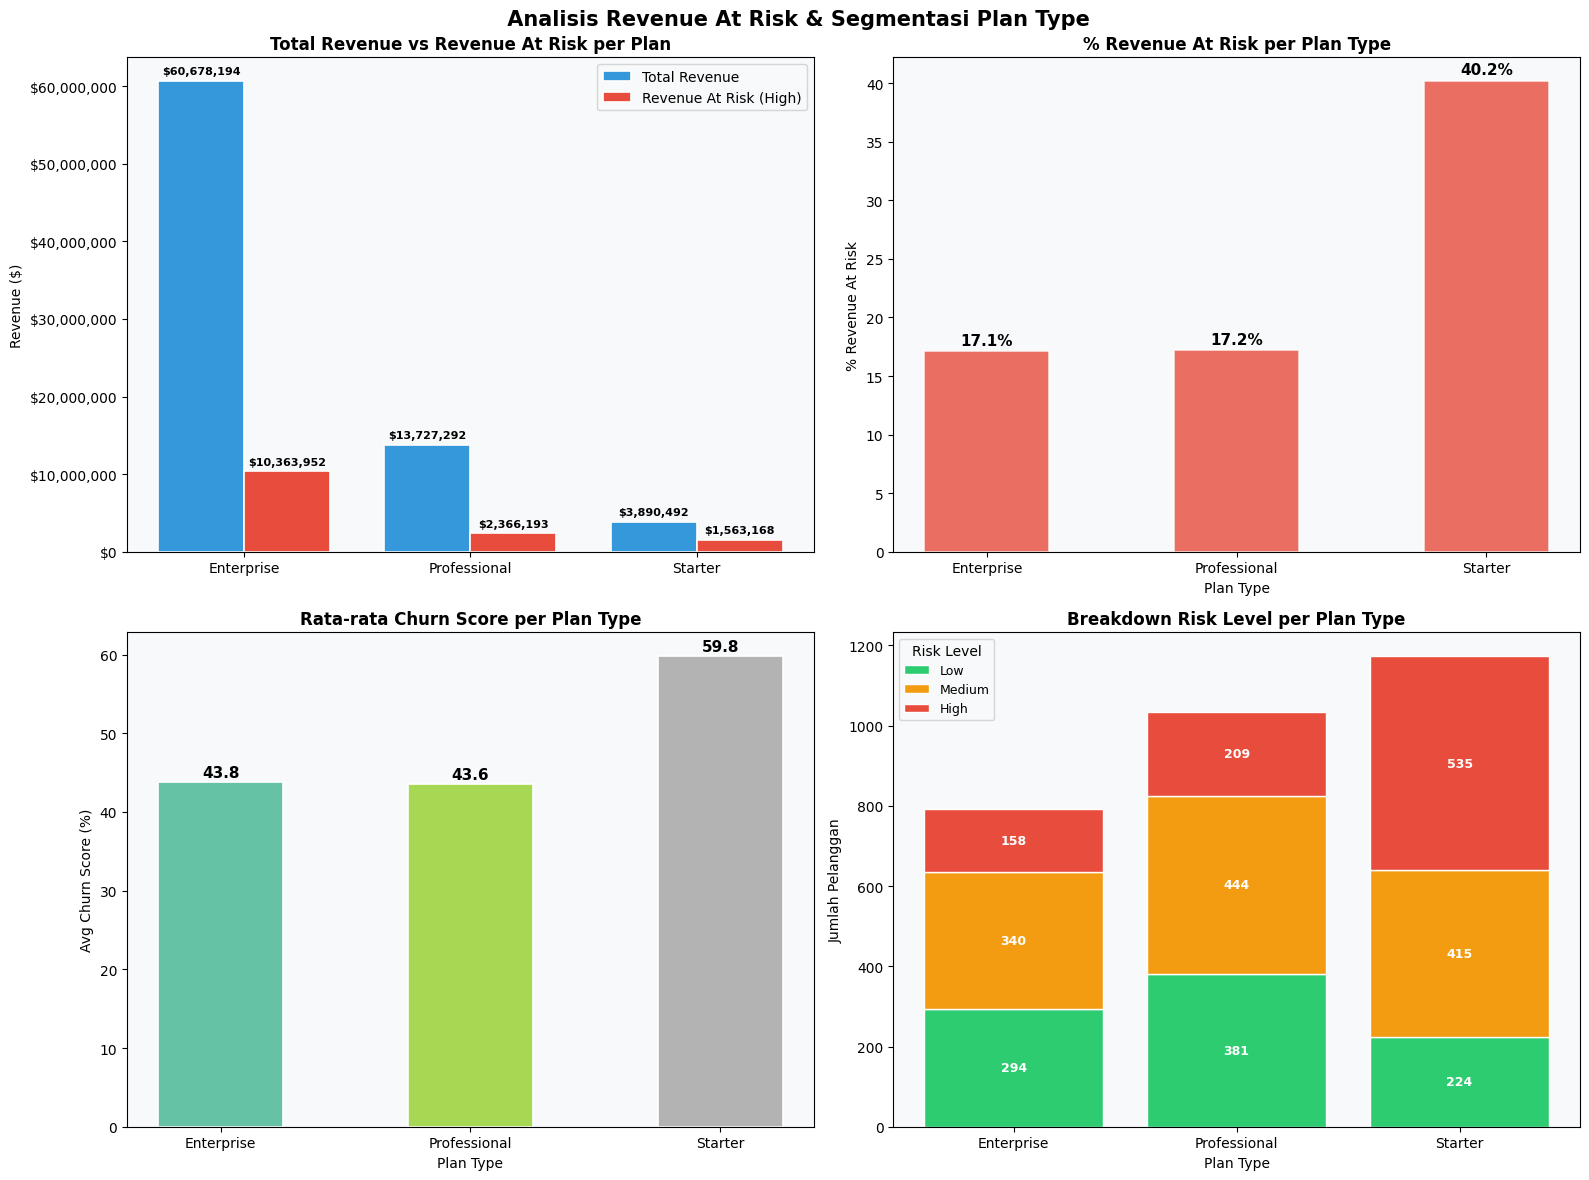

 Visualisasi 5 tersimpan: viz5_revenue_segment_analysis.png


In [ ]:
# ==========================================
#  VISUALISASI 5: Revenue At Risk & Segmentasi per Plan Type
# ==========================================
df_master_viz = pd.read_csv('master_data_clean.csv')
df_pred_viz2 = pd.read_csv('churn_prediction_results.csv')
df_comb_viz = df_master_viz.merge(
    df_pred_viz2[['customer_id', 'churn_score', 'risk_level', 'tenure_months']],
    on='customer_id', how='left'
)
df_comb_viz['plan_type'] = df_comb_viz['plan_type'].str.title()
df_comb_viz['revenue_high_risk_saja'] = df_comb_viz.apply(
    lambda row: row['total_payment_value'] if row['risk_level'] == 'High' else 0, axis=1
)

seg_sum = df_comb_viz.groupby('plan_type').agg(
    total_customers=('customer_id', 'count'),
    avg_churn_score=('churn_score', 'mean'),
    total_revenue=('total_payment_value', 'sum'),
    revenue_at_risk=('revenue_high_risk_saja', 'sum')
).reset_index()

seg_sum['pct_at_risk'] = (seg_sum['revenue_at_risk'] / seg_sum['total_revenue'] * 100).round(1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' Analisis Revenue At Risk & Segmentasi Plan Type',
             fontsize=15, fontweight='bold')

plan_colors = plt.cm.Set2(np.linspace(0, 1, len(seg_sum)))

# --- Panel 1: Total Revenue vs Revenue At Risk per plan ---
x_idx = np.arange(len(seg_sum))
w = 0.38
b1 = axes[0,0].bar(x_idx - w/2, seg_sum['total_revenue'], w, label='Total Revenue',
                    color='#3498db', edgecolor='white', linewidth=1.2)
b2 = axes[0,0].bar(x_idx + w/2, seg_sum['revenue_at_risk'], w, label='Revenue At Risk (High)',
                    color='#e74c3c', edgecolor='white', linewidth=1.2)
axes[0,0].set_title('Total Revenue vs Revenue At Risk per Plan', fontsize=12, fontweight='bold')
axes[0,0].set_xticks(x_idx)
axes[0,0].set_xticklabels(seg_sum['plan_type'], fontsize=10)
axes[0,0].set_ylabel('Revenue ($)', fontsize=10)
axes[0,0].legend(fontsize=10)
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0,0].text(bar.get_x()+bar.get_width()/2, h + max(seg_sum['total_revenue'])*0.01,
                   f'${h:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# --- Panel 2: % Revenue At Risk per plan ---
bars2 = axes[0,1].bar(seg_sum['plan_type'], seg_sum['pct_at_risk'], color='#e74c3c',
                       alpha=0.8, edgecolor='white', linewidth=1.2, width=0.5)
axes[0,1].set_title('% Revenue At Risk per Plan Type', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('% Revenue At Risk', fontsize=10)
axes[0,1].set_xlabel('Plan Type', fontsize=10)
for bar, val in zip(bars2, seg_sum['pct_at_risk']):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# --- Panel 3: Rata-rata Churn Score per plan ---
bars3 = axes[1,0].bar(seg_sum['plan_type'], seg_sum['avg_churn_score'],
                       color=plan_colors, edgecolor='white', linewidth=1.2, width=0.5)
axes[1,0].set_title('Rata-rata Churn Score per Plan Type', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Avg Churn Score (%)', fontsize=10)
axes[1,0].set_xlabel('Plan Type', fontsize=10)
for bar, val in zip(bars3, seg_sum['avg_churn_score']):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# --- Panel 4: Stacked Risk Level per plan ---
risk_plan = df_comb_viz.groupby(['plan_type', 'risk_level']).size().unstack(fill_value=0)
risk_order2 = ['Low', 'Medium', 'High']
risk_plan = risk_plan.reindex(columns=[c for c in risk_order2 if c in risk_plan.columns])
stack_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
bottom_vals = np.zeros(len(risk_plan))
for risk_col in risk_plan.columns:
    vals = risk_plan[risk_col].values
    axes[1,1].bar(risk_plan.index, vals, bottom=bottom_vals,
                  label=risk_col, color=stack_colors.get(risk_col, '#95a5a6'),
                  edgecolor='white', linewidth=1)
    for xi, (bot, val) in enumerate(zip(bottom_vals, vals)):
        if val > 0:
            axes[1,1].text(xi, bot + val/2, f'{val:,}', ha='center', va='center',
                           fontsize=9, fontweight='bold', color='white')
    bottom_vals += vals
axes[1,1].set_title('Breakdown Risk Level per Plan Type', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Plan Type', fontsize=10)
axes[1,1].set_ylabel('Jumlah Pelanggan', fontsize=10)
axes[1,1].legend(title='Risk Level', fontsize=9)

plt.tight_layout()
plt.savefig('viz5_revenue_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisasi 5 tersimpan: viz5_revenue_segment_analysis.png")


## 12: Menyimpan Arsitektur Komponen Pemodelan (Model Serialization)
Sel kode pamungkas ini menyimpan objek esensial yang sudah selesai dilatih oleh komputer (*LightGBM Model*, Pemroses Skala Data, Komponen Pengelompokan Segmen K-Means, serta Urutan Struktur Kolom) ke dalam bentuk artefak file serialisasi berekstensi `.pkl` menggunakan perpustakaan sistem terpadu `joblib`. Arsip modul komponen siap diintegrasikan kapanpun bagi kebutuhan arsitektur rekayasa *backend deployment* atau pembuatan *dashboard* web di masa mendatang.

In [ ]:
import joblib

# 1. save model lightgbm yang paling jago (indeks 0)
joblib.dump(best_model, 'model_churn_final.pkl')
print(f"✅ Model tersimpan: {best_model_name} (accuracy: {results[best_model_name]['accuracy']:.4f})")

# 2. save mesin scaling (biar angka di web sama kayak di notebook)
joblib.dump(scaler, 'scaler.pkl')

# 3. save mesin k-means (buat segmentasi pelanggan)
joblib.dump(kmeans, 'kmeans.pkl')

# 4. save daftar kolom (ini penting biar urutan datanya ga ketuker)
joblib.dump(x.columns.tolist(), 'model_columns.pkl')

print(" semua alat tempur (model, scaler, kmeans, columns) sukses disave!")

✅ Model tersimpan: LightGBM (accuracy: 0.9383)
 semua alat tempur (model, scaler, kmeans, columns) sukses disave!


In [ ]:
df_pred = pd.read_csv('churn_prediction_results.csv')
print(df_pred['risk_level'].value_counts())
print()
print(df_pred['churn_score'].describe())

risk_level
Medium    1199
High       902
Low        899
Name: count, dtype: int64

count    3000.000000
mean       50.000000
std        28.886787
min         0.000000
25%        25.000000
50%        50.000000
75%        75.000000
max       100.000000
Name: churn_score, dtype: float64
